# Using Fast Weights to Attend to the Recent Past — Summary

# https://arxiv.org/pdf/1610.06258

## Abstract
The paper introduces "fast weights," a third class of neural network variable that changes faster than standard (slow) weights but slower than neural activities. Fast weights implement a temporary, high-capacity associative memory that lets a recurrent network attend to its own recent hidden states without storing explicit copies of past activity vectors. The authors show that this mechanism, combined with layer normalization, improves performance over LSTMs and plain RNNs on associative retrieval, image classification via glimpses, facial expression recognition, and reinforcement learning tasks with partial observability.

## Problems
- Standard RNNs and LSTMs rely on only two timescales of memory: fast-changing neural activities (capacity $$O(H)$$) and slowly-learned weights (capacity $$O(H^2)$$), leaving no efficient mechanism for storing temporary, sequence-specific information at an intermediate timescale.
- Biological synapses exhibit short-term plasticity operating on the 100 ms–minutes timescale, a regime not well captured by either neural activation dynamics (too slow at that scale without attractor states) or long-term synaptic plasticity (too fast to engage).
- Existing architectures with external memory (Neural Turing Machines, Neural Stacks, Memory Networks) require biologically implausible structures and explicit read/write addressing decisions.

## Proposed Solutions
- Introduce fast weights, $$A(t)$$, that store an outer-product-based associative memory of recent hidden states and decay exponentially over time.
- Define the fast weight update rule:
$$A(t) = \lambda A(t-1) + \eta h(t) h(t)^T$$
- Use fast weights to modify the computation of the next hidden state through an iterative "inner loop" that settles over $$S$$ steps:
$$h_{s+1}(t+1) = f([Wh(t) + Cx(t)] + A(t)h_s(t+1))$$
- Show that this is mathematically equivalent to an attention mechanism over past hidden vectors, weighted by their scalar product with the current hidden vector and by a decay factor:
$$A(t)h_s(t+1) = \eta \sum_{\tau=1}^{t} \lambda^{t-\tau} h(\tau)\left[h(\tau)^T h_s(t+1)\right]$$
- Apply layer normalization within the inner loop to stabilize dynamics and reduce sensitivity to learning rate and decay hyperparameters:
$$h_{s+1}(t+1) = f(LN[Wh(t) + Cx(t) + A(t)h_s(t+1)])$$

## Purpose
The goal is to demonstrate that a neurally plausible, computationally simple mechanism—fast associative weights—can give recurrent networks a higher-capacity, short-term memory that improves sequence modeling without abandoning mini-batch training or requiring exotic external memory structures.

## Methodology
| Component | Description |
|---|---|
| Fast weight formulation | Outer-product Hebbian storage rule with exponential decay |
| Base architecture | Single recurrent hidden layer (ReLU) augmented with fast weights |
| Comparison models | IRNN, standard LSTM, Associative LSTM, ConvNet (task-dependent) |
| Optimization | Adam optimizer, mini-batches of size 128 |
| Tasks | Associative key-value retrieval, MNIST classification via glimpses, facial expression recognition (MultiPIE), partially observable RL task ("Catch") |
| RL Method | Asynchronous advantage actor-critic (A3C) |

Experiments varied model size (recurrent unit count) and memory demands (e.g., number of key-value pairs $$R$$, screen size $$N$$ and observability window $$M$$) to isolate the effect of the added fast-weight memory capacity.

## Results
- **Associative retrieval**: Fast weights substantially outperformed IRNN, LSTM, and Associative LSTM, achieving near-zero error rates across $$R=20,50,100$$ while other models degraded sharply as $$R$$ increased.
- **MNIST via glimpses**: Multi-level fast weights model achieved error rates competitive with a ConvNet baseline and consistently better than LSTM/IRNN, especially with limited hidden units.
- **Facial expression recognition (MultiPIE)**: Fast weights (86.34% accuracy) outperformed LSTM (81.32%) and IRNN (81.11%), though a ConvNet performed best (88.23%), attributed to weight-sharing and simultaneous access to all spatial information.
- **RL Catch task**: The fast-weights RNN policy learned faster than plain RNN and LSTM policies, with the advantage growing on the larger, more memory-demanding variant ($$N=24, M=5$$).

## Conclusions
Fast weights provide an effective, biologically motivated mechanism for short-term memory in recurrent networks, functioning as an attention mechanism over recent hidden states without requiring stored copies of activity patterns. Layer normalization is critical for stabilizing this mechanism. The approach consistently improves performance over LSTM baselines when the number of recurrent units is limited, and it generalizes across supervised (retrieval, classification) and reinforcement learning settings. The authors argue this addresses a long-standing theoretical gap regarding how neural networks might implement recursive, resource-efficient processing analogous to human cognition, while acknowledging that combining fast weights with learned (rather than fixed) attention policies remains future work.

# Mathematical and Statistical Content Summary

## 1. Memory Capacity Formulas
**Standard RNN/LSTM memory capacities:**
- Short-term (hidden activity) memory capacity: $$O(H)$$, where $$H$$ = number of hidden units.
- Long-term (weight matrix) memory capacity: $$O(H^2) + O(IH) + O(HO)$$, where $$I$$, $$O$$ are input/output unit counts.

**Role:** Establishes the motivation for fast weights — ordinary architectures only offer these two memory scales, leaving a gap for intermediate-timescale, higher-capacity storage.

## 2. Hopfield Network Capacity Bound
An auto-associative memory with $$N^2$$ weights can store on the order of $$0.15N$$ binary vectors using a simple outer-product (Hopfield) storage rule, with each weight requiring about $$\log(N)$$ bits.

**Role:** Provides theoretical context for how much information can be packed into weight-based associative memories, motivating the outer-product storage rule chosen for fast weights (simplicity over maximal capacity).

## 3. Fast Weight Update Rule (Equation 1)
$$A(t) = \lambda A(t-1) + \eta h(t) h(t)^T$$

- $$A(t)$$: fast weight matrix at time $$t$$.
- $$\lambda$$: decay rate (how quickly old memories fade).
- $$\eta$$: learning rate (how strongly new states are written in).
- $$h(t)h(t)^T$$: outer product of the current hidden state with itself.

**Role:** This is the core mechanism — it is a Hebbian-like rule that continuously overlays new "memories" (outer products of hidden states) onto a decaying matrix, allowing many past states to be superimposed in one matrix without explicit addressing.

## 4. Hidden State Update: Preliminary Vector
$$h_0(t+1) = f(Wh(t) + Cx(t))$$

- $$W$$: slow recurrent transition weights.
- $$C$$: slow input weights.
- $$f(\cdot)$$: nonlinearity (e.g., ReLU).

**Role:** Computes the standard RNN update before fast-weight influence is applied — this sets the "boundary condition" for the inner loop.

## 5. Inner Loop Iterative Settling (Equation 2)
$$h_{s+1}(t+1) = f\big([Wh(t) + Cx(t)] + A(t)h_s(t+1)\big)$$

- Runs for $$S$$ steps, progressively refining $$h_0(t+1) \to h_S(t+1) = h(t+1)$$.
- The bracketed term is held fixed (sustained boundary condition) while the fast-weight contribution iteratively adjusts the hidden state.

**Role:** This is the mechanism by which the fast associative memory actually influences computation — iterative refinement lets the hidden state "settle" toward states resembling relevant recent history.

## 6. Explicit (Unrolled) Form of Fast Weights (Equation 3)
$$A(t) = \eta \sum_{\tau=1}^{t} \lambda^{t-\tau} h(\tau) h(\tau)^T$$

**Role:** Shows that the recursive update (Eq. 1) is equivalent to a weighted sum over all past hidden states, each raised to a power of the decay rate depending on how long ago it occurred — i.e., exponential forgetting.

## 7. Fast Weight Action as Attention (Equation 4)
$$A(t)h_s(t+1) = \eta \sum_{\tau=1}^{t} \lambda^{t-\tau} h(\tau)\left[h(\tau)^T h_s(t+1)\right]$$

- The scalar $$h(\tau)^T h_s(t+1)$$ measures similarity (dot product) between a past hidden state and the current one.
- This scalar weights how much each past state $$h(\tau)$$ contributes to the update.

**Role:** This is the key mathematical insight of the paper: applying the fast weight matrix is mathematically identical to an attention mechanism over past hidden states, where "attention weight" is the dot-product similarity, scaled by exponential decay — avoiding the need for a separately learned attention/alignment function (as in seq2seq models).

## 8. Layer-Normalized Fast Weight Update (Equation 5)
$$h_{s+1}(t+1) = f\big(LN[Wh(t) + Cx(t) + A(t)h_s(t+1)]\big)$$

- $$LN[\cdot]$$: layer normalization — recenters and rescales the summed inputs using their mean and variance across units, then applies a learned bias and gain.

**Role:** Prevents the scalar products in the attention-like mechanism from exploding or vanishing due to varying hidden vector norms; empirically found necessary for stable, robust training across hyperparameter settings.

## 9. Statistical/Evaluation Methods
- **Classification error rate**: proportion of misclassified test examples, used as the primary metric in Tables 1–2 (associative retrieval, MNIST).
- **Test accuracy (%)**: used for facial expression recognition (Table 3).
- **Negative log-likelihood curves**: used to compare convergence speed across models (Figure 2).
- **Average reward curves with variance bands**: used in the RL "Catch" experiments (Figure 5), showing mean performance and spread (likely standard deviation/error) across training runs, averaged over the top 5 hyperparameter-selected models.
- **Hyperparameter selection via grid search / random search**: grid search used for supervised tasks; random search used for RL task hyperparameters (learning rate, number of Hebbian/inner-loop steps, fast weight learning rate and decay).

**Role:** These are standard empirical machine learning evaluation tools rather than novel statistical methods — they quantify predictive performance, learning speed, and stability, and are used comparatively across models rather than via formal hypothesis testing.

## Summary of Mathematical Contribution
The paper's mathematical core is compact: a Hebbian outer-product update rule (Eq. 1) that decays exponentially, whose recursive form (Eq. 3) can be shown algebraically (Eq. 4) to implement a similarity-based attention mechanism over recent hidden states — with layer normalization (Eq. 5) added purely for numerical stability. All other mathematical content (capacity formulas, Hopfield bounds) serves as background justification rather than being novel results of this paper.

# Research Gaps and Proposed Solutions

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Neural networks are conventionally restricted to only two types of variable: fast-changing neural activities and slowly-learned weights. | This leaves no mechanism for storing temporary, sequence-specific information at an intermediate timescale, despite no principled reason for the restriction. | Introduce "fast weights" — a third variable type that changes more slowly than activities but much faster than standard weights, enabling an additional memory timescale. |
| 2 | Standard RNNs store the entire history of a sequence in the hidden activity vector, which has limited capacity, $$O(H)$$. | Short-term memory capacity is tightly bounded by the number of hidden units, constraining how much sequence-specific information can be retained. | Use fast weights as an associative memory with capacity closer to $$O(H^2)$$, allowing much more temporary information to be stored without enlarging the hidden state. |
| 3 | LSTMs improve long-range dependency modeling via gating and additive hidden-state updates, but still rely fundamentally on the same $$O(H)$$ short-term memory. | Even with gating mechanisms, LSTMs cannot exceed the fundamental capacity limits of the hidden activity vector for storing recent sequence history. | Augment RNNs with a fast associative weight matrix $$A(t)$$ that stores recent hidden states via outer products, decoupling temporary memory capacity from hidden state size. |
| 4 | Biological evidence suggests working memory and priming operate on a 100 ms–minutes timescale via short-term synaptic plasticity, not captured by standard activation-based memory models. | Prior ANN research focused almost exclusively on activation dynamics for temporary state, inconsistent with neuroscientific evidence for synapse-level short-term memory mechanisms. | Model temporary memory using synapse-like fast weights that decay over time, offering a more biologically plausible mechanism aligned with known short-term plasticity phenomena. |
| 5 | Early theoretical proposals (Hinton and Plaut, 1987; Schmidhuber, 1993) suggested fast weights for recursive computation but were never implemented or trained end-to-end. | The idea remained purely conceptual, with no practical demonstration of effectiveness in trainable, modern neural architectures. | Provide a concrete, end-to-end trainable formulation using an outer-product Hebbian update rule combined with backpropagation through an iterative "inner loop." |
| 6 | External memory architectures (Neural Turing Machines, Neural Stacks, Memory Networks) require explicit addressing decisions (where/when to read or write) and structures with unclear biological plausibility. | These models are computationally complex and difficult to justify as models of real neural computation, since structures like an NTM "tape" have no clear synaptic analogue. | Use a fast associative memory that updates continuously via superimposed writes (no explicit addressing), which can plausibly be implemented by rapidly changing synapses. |
| 7 | Naively applying per-sequence fast weight matrices is incompatible with efficient mini-batch training, since each sequence would require a distinct weight matrix. | This would impose a substantial computational penalty, discouraging practical adoption of associative-memory-based RNNs. | Exploit the mathematical equivalence between the fast weight matrix and a weighted sum over stored past hidden vectors (Eq. 3–4), enabling efficient computation compatible with mini-batches. |
| 8 | The scalar products underlying the fast-weight/attention mechanism can vanish or explode depending on hidden vector norms, destabilizing training. | Without normalization, models using this mechanism are highly sensitive to learning rate and decay hyperparameters, hindering robust training. | Apply layer normalization within the inner-loop update (Eq. 5), which is shown empirically to stabilize dynamics and reduce hyperparameter sensitivity. |
| 9 | Visual attention models integrate sequences of glimpses using only the hidden state, forcing it to jointly store partial results and perform integration, limiting capacity for complex, multi-scale glimpse policies. | Hidden-state-only integration is inefficient and constrains models to overly simplistic, rigid glimpse policies that do not scale well to multi-level visual hierarchies. | Use fast weights as a neurally plausible temporary "cache" to store partial glimpse-level results, freeing the hidden state to focus on integration and final classification. |
| 10 | The benefits of higher-capacity temporary memory for sequential decision-making (reinforcement learning) were largely unexplored, unlike in supervised sequence learning. | Prior RL work using recurrent policies relied on standard RNN/LSTM memory, without evaluating higher-capacity, faster-decaying memory mechanisms for partial observability. | Evaluate a fast-weights RNN as a policy representation in an actor-critic (A3C) framework on a partially observable task, demonstrating faster learning than RNN/LSTM baselines. |

In [1]:
# ============================================================
# EDUCATIONAL REPLICATION:
# "Using Fast Weights to Attend to the Recent Past" (Ba, Hinton, Mnih, Leibo, Ionescu, 2016)
# Simplified implementation applied to CIFAR-10 image classification via a
# sequence-of-glimpses recurrent model augmented with FAST WEIGHTS (Hebbian
# associative memory + layer normalization), exactly as described in the paper.
#
# NOTE: This code is NOT executed here. It is meant to be copied into a
# Google Colab / Jupyter cell and run there.
# ============================================================

# ---------------------------------------------------------------
# 0. IMPORTS
# ---------------------------------------------------------------
import io
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset  # HuggingFace datasets (mandatory source)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import cm

from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

# ---------------------------------------------------------------
# GLOBAL WHITE-THEME SETTINGS (applied globally + reinforced per-axis later)
# ---------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "grid.color": "#d9d9d9",
    "legend.labelcolor": "black",
    "font.size": 10,
})

In [2]:
# ---------------------------------------------------------------
# REPRODUCIBILITY
# ---------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ---------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, exact order, labels 0-9)
# ---------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ---------------------------------------------------------------
# 2. DATASET PREPARATION (HuggingFace CIFAR-10 — mandatory source)
# ---------------------------------------------------------------
# Load CIFAR-10 exclusively from HuggingFace (never torchvision.datasets.CIFAR10)
ds = load_dataset("uoft-cs/cifar10")

# Transform pipelines: resize to 64x64 so we can carve the image into
# non-overlapping "glimpse" patches, mimicking the paper's glimpse-sequence
# visual attention experiments (Section 4.2 / 4.3).
train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset.
    Reads the 'img' field as a PIL image, converts to RGB, applies the
    given torchvision transform, and returns (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(sample["label"])
        return img_tensor, label


# Wrap full splits
train_full = HFCifar10Dataset(ds["train"], train_transform)
test_full = HFCifar10Dataset(ds["test"], test_transform)

# Take small subsets for a fast, educational 5-epoch run
train_subset = Subset(train_full, list(range(2000)))
test_subset = Subset(test_full, list(range(400)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False, num_workers=2)

In [5]:
# ---------------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------------
sanity_images, sanity_labels = next(iter(train_loader))
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Shape of one batch of images:", sanity_images.shape)
print("Label range: [{}, {}]".format(sanity_labels.min().item(), sanity_labels.max().item()))
print("First 8 class names in batch:", [CLASS_NAMES[l] for l in sanity_labels[:8].tolist()])

Number of training samples: 2000
Number of test samples: 400
Shape of one batch of images: torch.Size([64, 3, 64, 64])
Label range: [0, 9]
First 8 class names in batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [6]:
# ---------------------------------------------------------------
# 3. MODEL DEFINITION
# ---------------------------------------------------------------
#
# The paper's core idea: augment a recurrent network with a FAST WEIGHT
# matrix A(t) that acts as a temporary, high-capacity associative memory.
#
#   A(t) = lambda * A(t-1) + eta * h(t) h(t)^T          (Eq. 1)
#
# The next hidden state is computed via an iterative "inner loop" that
# settles for S steps, using the fast weights as an attention-like
# correction term, stabilized with Layer Normalization:
#
#   h_{s+1}(t+1) = f( LN[ W h(t) + C x(t) + A(t) h_s(t+1) ] )   (Eq. 5)
#
# Instead of materializing the full H x H fast-weight matrix, we use the
# efficient equivalent form (Eq. 4), which is just attention over the
# stored sequence of past hidden states weighted by decayed similarity.
#
# We apply this recurrent fast-weight core over a SEQUENCE OF GLIMPSES
# (non-overlapping image patches), echoing the paper's visual-attention
# experiments (Section 4.2/4.3), where fast weights act as a temporary
# "cache" integrating information across glimpses.

GLIMPSE_GRID = 4          # 4x4 grid -> 16 glimpses per image (64x64 -> 16x16 patches)
PATCH_SIZE = 64 // GLIMPSE_GRID
EMBED_DIM = 128           # dimensionality of glimpse embeddings / hidden state
INNER_LOOP_STEPS = 2      # S: number of fast-weight "inner loop" settling steps
FAST_LR = 0.5             # eta: fast weight learning rate (as used in the paper)
FAST_DECAY = 0.95         # lambda: fast weight decay rate (as used in the paper)


class GlimpseEmbedder(nn.Module):
    """
    Small CNN that embeds a single image glimpse (patch) into a fixed-size
    vector. This plays the role of the input embedding C*x(t) in the paper.
    """
    def __init__(self, embed_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                     # patch_size -> patch_size/2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, embed_dim)

    def forward(self, x):
        # x: (batch, 3, patch, patch)
        feat = self.conv(x).flatten(1)
        return self.fc(feat)  # (batch, embed_dim)


class FastWeightsRNNCell(nn.Module):
    """
    Implements ONE recurrent step of the Fast Weights model:
        h0 = f(W h(t) + C x(t))                       (preliminary vector)
        for s in range(S):
            h_{s+1} = f(LN[ boundary + A h_s ])        (inner loop, Eq. 5)
        A_new = lambda * A + eta * h(t+1) h(t+1)^T     (fast weight update, Eq. 1)

    The fast weight term A*h_s is computed EFFICIENTLY using the equivalent
    similarity-weighted sum over stored past hidden vectors (Eq. 3-4),
    avoiding materializing the full (H x H) matrix.
    """
    def __init__(self, input_dim, hidden_dim, decay=FAST_DECAY, fast_lr=FAST_LR,
                 inner_steps=INNER_LOOP_STEPS):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.decay = decay
        self.fast_lr = fast_lr
        self.inner_steps = inner_steps

        # Slow weights: W (hidden->hidden), C (input->hidden)
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.C = nn.Linear(input_dim, hidden_dim, bias=True)

        # Layer normalization applied at every inner-loop iteration (Eq. 5)
        self.ln = nn.LayerNorm(hidden_dim)

    def forward(self, x_t, h_prev, past_hiddens):
        """
        x_t:          (batch, input_dim)          current glimpse embedding
        h_prev:       (batch, hidden_dim)         previous hidden state
        past_hiddens: list of (batch, hidden_dim) all previous hidden states
                      in this sequence (used to emulate the fast weight
                      matrix A via Eq. 3-4, weighted by exponential decay).
        Returns: new hidden state h_{t+1}
        """
        # --- Preliminary vector: boundary condition (sustained across inner loop) ---
        boundary = self.W(h_prev) + self.C(x_t)          # (batch, hidden_dim)
        h_s = F.relu(boundary)

        # --- Inner loop: iteratively apply fast-weight attention correction ---
        if len(past_hiddens) > 0:
            # Stack past hidden states: (T_past, batch, hidden_dim)
            past_stack = torch.stack(past_hiddens, dim=0)
            T_past = past_stack.shape[0]
            # Exponential decay weights: lambda^(t - tau), tau = 1..t (most recent = largest weight)
            decay_powers = self.decay ** torch.arange(T_past - 1, -1, -1,
                                                        device=x_t.device, dtype=x_t.dtype)
            decay_powers = decay_powers.view(T_past, 1, 1)  # (T_past, 1, 1)

            for _ in range(self.inner_steps):
                # Similarity of current h_s with each past hidden state (Eq. 4 core term)
                # (T_past, batch, hidden_dim) . (batch, hidden_dim) -> (T_past, batch, 1)
                sim = (past_stack * h_s.unsqueeze(0)).sum(dim=-1, keepdim=True)
                # Weighted sum of past states by similarity and decay -> fast-weight term
                fast_term = self.fast_lr * (decay_powers * sim * past_stack).sum(dim=0)
                h_s = F.relu(self.ln(boundary + fast_term))
        else:
            # No history yet (first glimpse): fast weight term is zero
            h_s = F.relu(self.ln(boundary))

        return h_s


class FastWeightsGlimpseNet(nn.Module):
    """
    Full model:
      1. Split image into a grid of glimpses (patches).
      2. Embed each glimpse with a small CNN (GlimpseEmbedder).
      3. Process the glimpse sequence with the FastWeightsRNNCell,
         maintaining a growing associative (fast-weight) memory of
         all past glimpse-hidden-states.
      4. Classify using the final hidden state.
    """
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 grid=GLIMPSE_GRID):
        super().__init__()
        self.grid = grid
        self.embedder = GlimpseEmbedder(embed_dim)
        self.cell = FastWeightsRNNCell(embed_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.hidden_dim = hidden_dim

    def extract_glimpses(self, images):
        """
        images: (batch, 3, 64, 64)
        Returns: list of (batch, 3, patch, patch) glimpses, in raster-scan order.
        """
        b, c, H, W = images.shape
        p = H // self.grid
        glimpses = []
        for i in range(self.grid):
            for j in range(self.grid):
                patch = images[:, :, i * p:(i + 1) * p, j * p:(j + 1) * p]
                glimpses.append(patch)
        return glimpses

    def forward(self, images):
        batch_size = images.shape[0]
        glimpses = self.extract_glimpses(images)

        h = torch.zeros(batch_size, self.hidden_dim, device=images.device)
        past_hiddens = []

        for patch in glimpses:
            x_t = self.embedder(patch)
            h = self.cell(x_t, h, past_hiddens)
            past_hiddens.append(h)

        logits = self.classifier(h)
        return logits


model = FastWeightsGlimpseNet().to(DEVICE)

In [7]:
# ---------------------------------------------------------------
# 4. LOSS & OPTIMIZER
# ---------------------------------------------------------------
# The paper's classification tasks (MNIST, MultiPIE) use a single
# cross-entropy classification loss -> our only loss component.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 5

In [8]:
# ---------------------------------------------------------------
# 5. TRAINING LOOP + VALIDATION/EVALUATION
# ---------------------------------------------------------------
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "epoch_per_class_acc": [],   # list of arrays, one per epoch, len = NUM_CLASSES
}


def evaluate(loader):
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_preds, all_labels, all_confidences = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            probs = F.softmax(logits, dim=1)
            conf, preds = probs.max(dim=1)

            total_loss += loss.item() * imgs.size(0)
            total_correct += (preds == labels).sum().item()
            total_count += imgs.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_confidences.append(conf.cpu())

    avg_loss = total_loss / total_count
    avg_acc = total_correct / total_count
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_confidences = torch.cat(all_confidences).numpy()
    return avg_loss, avg_acc, all_preds, all_labels, all_confidences


print("\nStarting training...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss, running_correct, running_count = 0.0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        running_loss += loss.item() * imgs.size(0)
        running_correct += (preds == labels).sum().item()
        running_count += imgs.size(0)

    train_loss = running_loss / running_count
    train_acc = running_correct / running_count

    # Validation/Evaluation pass on the test subset
    val_loss, val_acc, val_preds, val_labels, val_conf = evaluate(test_loader)

    # Per-class accuracy for this epoch (for the epoch-wise heatmap, Panel F)
    per_class_acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = (val_labels == c)
        per_class_acc[c] = (val_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["epoch_per_class_acc"].append(per_class_acc)

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Starting training...

Epoch 1/5 | Train Loss: 2.2323 | Train Acc: 0.1590 | Val Loss: 2.1929 | Val Acc: 0.1850
Epoch 2/5 | Train Loss: 2.1477 | Train Acc: 0.1995 | Val Loss: 2.1168 | Val Acc: 0.1900
Epoch 3/5 | Train Loss: 2.1255 | Train Acc: 0.1995 | Val Loss: 2.1513 | Val Acc: 0.1925
Epoch 4/5 | Train Loss: 2.1126 | Train Acc: 0.2225 | Val Loss: 2.1487 | Val Acc: 0.1950
Epoch 5/5 | Train Loss: 2.1015 | Train Acc: 0.2040 | Val Loss: 2.1213 | Val Acc: 0.1750


In [9]:
# ---------------------------------------------------------------
# 6. PREDICTION PIPELINE (final evaluation pass for visualizations)
# ---------------------------------------------------------------
final_val_loss, final_val_acc, final_preds, final_labels, final_conf = evaluate(test_loader)

# Grab one batch of images (denormalized) for sample-prediction visualization
sample_imgs, sample_labels = next(iter(test_loader))
with torch.no_grad():
    sample_logits = model(sample_imgs.to(DEVICE))
    sample_probs = F.softmax(sample_logits, dim=1)
    sample_conf, sample_preds = sample_probs.max(dim=1)
sample_preds = sample_preds.cpu().numpy()
sample_conf = sample_conf.cpu().numpy()
sample_labels_np = sample_labels.numpy()


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

In [10]:
# ---------------------------------------------------------------
# 7. STANDALONE EDUCATIONAL VISUALIZATIONS (individual figures)
# ---------------------------------------------------------------

# --- Training / Validation loss curves ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.set_facecolor("white")
epochs_range = range(1, NUM_EPOCHS + 1)
ax1.plot(epochs_range, history["train_loss"], marker="o", color="tab:blue", label="Train Loss")
ax1.plot(epochs_range, history["val_loss"], marker="o", color="tab:red", label="Validation Loss")
ax1.set_title("Training vs Validation Loss", color="black")
ax1.set_xlabel("Epoch", color="black")
ax1.set_ylabel("Loss", color="black")
ax1.legend(labelcolor="black")
ax1.grid(True, color="#d9d9d9")
plt.close(fig1)  # keep figure object for reuse in dashboard; not shown standalone

# --- Training / Validation accuracy curves ---
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.set_facecolor("white")
ax2.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Acc")
ax2.plot(epochs_range, history["val_acc"], marker="o", color="tab:red", label="Validation Acc")
ax2.set_title("Training vs Validation Accuracy", color="black")
ax2.set_xlabel("Epoch", color="black")
ax2.set_ylabel("Accuracy", color="black")
ax2.legend(labelcolor="black")
ax2.grid(True, color="#d9d9d9")
plt.close(fig2)

# --- Confusion matrix (normalized) ---
cm_raw = confusion_matrix(final_labels, final_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm_raw.astype(float) / (cm_raw.sum(axis=1, keepdims=True) + 1e-9)

/tmp/ipykernel_1651/3077209916.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)


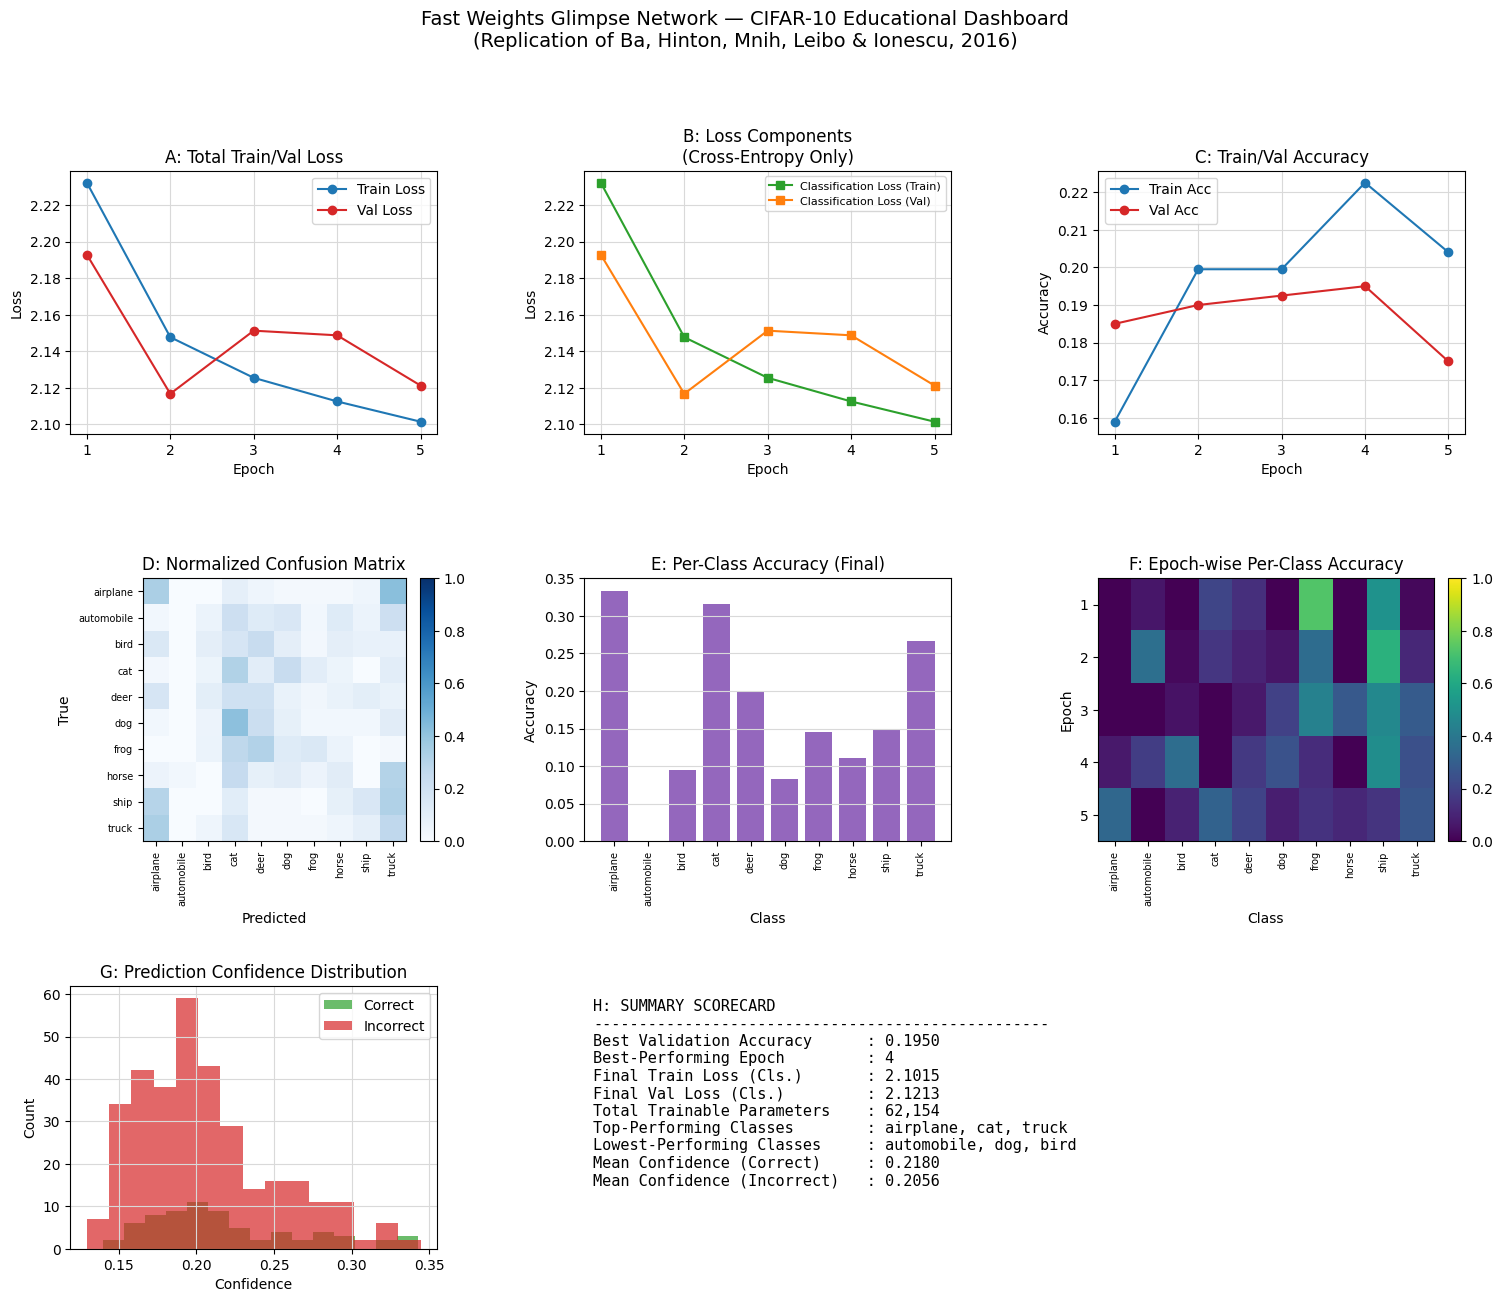

In [11]:
# ---------------------------------------------------------------
# 8. FINAL SUMMARY DASHBOARD (Panels A-H, 3-row GridSpec)
# ---------------------------------------------------------------

best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

per_class_acc_final = np.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    mask = (final_labels == c)
    per_class_acc_final[c] = (final_preds[mask] == c).mean() if mask.sum() > 0 else 0.0

top_classes_idx = np.argsort(per_class_acc_final)[::-1][:3]
low_classes_idx = np.argsort(per_class_acc_final)[:3]

correct_mask = (final_preds == final_labels)
mean_conf_correct = final_conf[correct_mask].mean() if correct_mask.sum() > 0 else 0.0
mean_conf_incorrect = final_conf[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0.0

fig = plt.figure(figsize=(18, 14), facecolor="white")
gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

# ---- Panel A: Total training & validation loss ----
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_loss"], marker="o", color="tab:blue", label="Train Loss")
axA.plot(epochs_range, history["val_loss"], marker="o", color="tab:red", label="Val Loss")
axA.set_title("A: Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black")
axA.grid(True, color="#d9d9d9")
for spine in axA.spines.values():
    spine.set_color("black")

# ---- Panel B: Component-specific losses ----
# This paper uses a single classification cross-entropy loss (no auxiliary
# objectives), so Panel B automatically reduces to that single component,
# shown as its own dedicated sub-curve to satisfy the "one panel per
# loss component" requirement.
axB = fig.add_subplot(gs[0, 1])
axB.set_facecolor("white")
axB.plot(epochs_range, history["train_loss"], marker="s", color="tab:green",
         label="Classification Loss (Train)")
axB.plot(epochs_range, history["val_loss"], marker="s", color="tab:orange",
         label="Classification Loss (Val)")
axB.set_title("B: Loss Components\n(Cross-Entropy Only)", color="black")
axB.set_xlabel("Epoch", color="black")
axB.set_ylabel("Loss", color="black")
axB.legend(labelcolor="black", fontsize=8)
axB.grid(True, color="#d9d9d9")
for spine in axB.spines.values():
    spine.set_color("black")

# ---- Panel C: Training & validation accuracy ----
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], marker="o", color="tab:red", label="Val Acc")
axC.set_title("C: Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black")
axC.grid(True, color="#d9d9d9")
for spine in axC.spines.values():
    spine.set_color("black")

# ---- Panel D: Normalized confusion matrix ----
axD = fig.add_subplot(gs[1, 0])
im = axD.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized Confusion Matrix", color="black")
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(cbar.ax.get_yticklabels(), color="black")
for spine in axD.spines.values():
    spine.set_color("black")

# ---- Panel E: Per-class accuracy bar chart ----
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
bars = axE.bar(CLASS_NAMES, per_class_acc_final, color="tab:purple")
axE.set_title("E: Per-Class Accuracy (Final)", color="black")
axE.set_xlabel("Class", color="black")
axE.set_ylabel("Accuracy", color="black")
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.tick_params(axis="y", colors="black")
axE.grid(True, axis="y", color="#d9d9d9")
for spine in axE.spines.values():
    spine.set_color("black")

# ---- Panel F: Epoch-wise per-class accuracy heatmap ----
axF = fig.add_subplot(gs[1, 2])
heatmap_data = np.stack(history["epoch_per_class_acc"], axis=0)  # (epochs, classes)
imF = axF.imshow(heatmap_data, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_title("F: Epoch-wise Per-Class Accuracy", color="black")
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([str(e + 1) for e in range(NUM_EPOCHS)], color="black")
cbarF = fig.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(cbarF.ax.get_yticklabels(), color="black")
for spine in axF.spines.values():
    spine.set_color("black")

# ---- Panel G: Confidence distribution histogram ----
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(final_conf[correct_mask], bins=15, alpha=0.7, color="tab:green", label="Correct")
axG.hist(final_conf[~correct_mask], bins=15, alpha=0.7, color="tab:red", label="Incorrect")
axG.set_title("G: Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black")
axG.grid(True, color="#d9d9d9")
for spine in axG.spines.values():
    spine.set_color("black")

# ---- Panel H: Text-based summary scorecard ----
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")
summary_text = (
    "H: SUMMARY SCORECARD\n"
    "--------------------------------------------------\n"
    f"Best Validation Accuracy      : {best_val_acc:.4f}\n"
    f"Best-Performing Epoch         : {best_val_epoch}\n"
    f"Final Train Loss (Cls.)       : {history['train_loss'][-1]:.4f}\n"
    f"Final Val Loss (Cls.)         : {history['val_loss'][-1]:.4f}\n"
    f"Total Trainable Parameters    : {total_params:,}\n"
    f"Top-Performing Classes        : "
    f"{', '.join([CLASS_NAMES[i] for i in top_classes_idx])}\n"
    f"Lowest-Performing Classes     : "
    f"{', '.join([CLASS_NAMES[i] for i in low_classes_idx])}\n"
    f"Mean Confidence (Correct)     : {mean_conf_correct:.4f}\n"
    f"Mean Confidence (Incorrect)   : {mean_conf_incorrect:.4f}\n"
)
axH.text(0.01, 0.95, summary_text, transform=axH.transAxes,
         fontsize=11, verticalalignment="top", color="black", family="monospace")

fig.suptitle(
    "Fast Weights Glimpse Network — CIFAR-10 Educational Dashboard\n"
    "(Replication of Ba, Hinton, Mnih, Leibo & Ionescu, 2016)",
    color="black", fontsize=14, y=0.995
)

# ---- Extra: sample predictions grid (embedded as inset info via Panel H context) ----
# (Sample predictions are also produced as a separate quick-reference figure below,
#  consistent with the "sample predictions with true/predicted labels" requirement.)
fig_samples, axes_samples = plt.subplots(2, 4, figsize=(12, 6), facecolor="white")
for idx, ax in enumerate(axes_samples.flat):
    ax.set_facecolor("white")
    img_np = denormalize(sample_imgs[idx])
    ax.imshow(img_np)
    true_name = CLASS_NAMES[sample_labels_np[idx]]
    pred_name = CLASS_NAMES[sample_preds[idx]]
    color = "green" if true_name == pred_name else "red"
    ax.set_title(f"T: {true_name}\nP: {pred_name} ({sample_conf[idx]:.2f})",
                 color=color, fontsize=9)
    ax.axis("off")
fig_samples.suptitle("Sample Predictions (True vs Predicted)", color="black", fontsize=13)
plt.close(fig_samples)  # not displayed standalone; dashboard is the final output

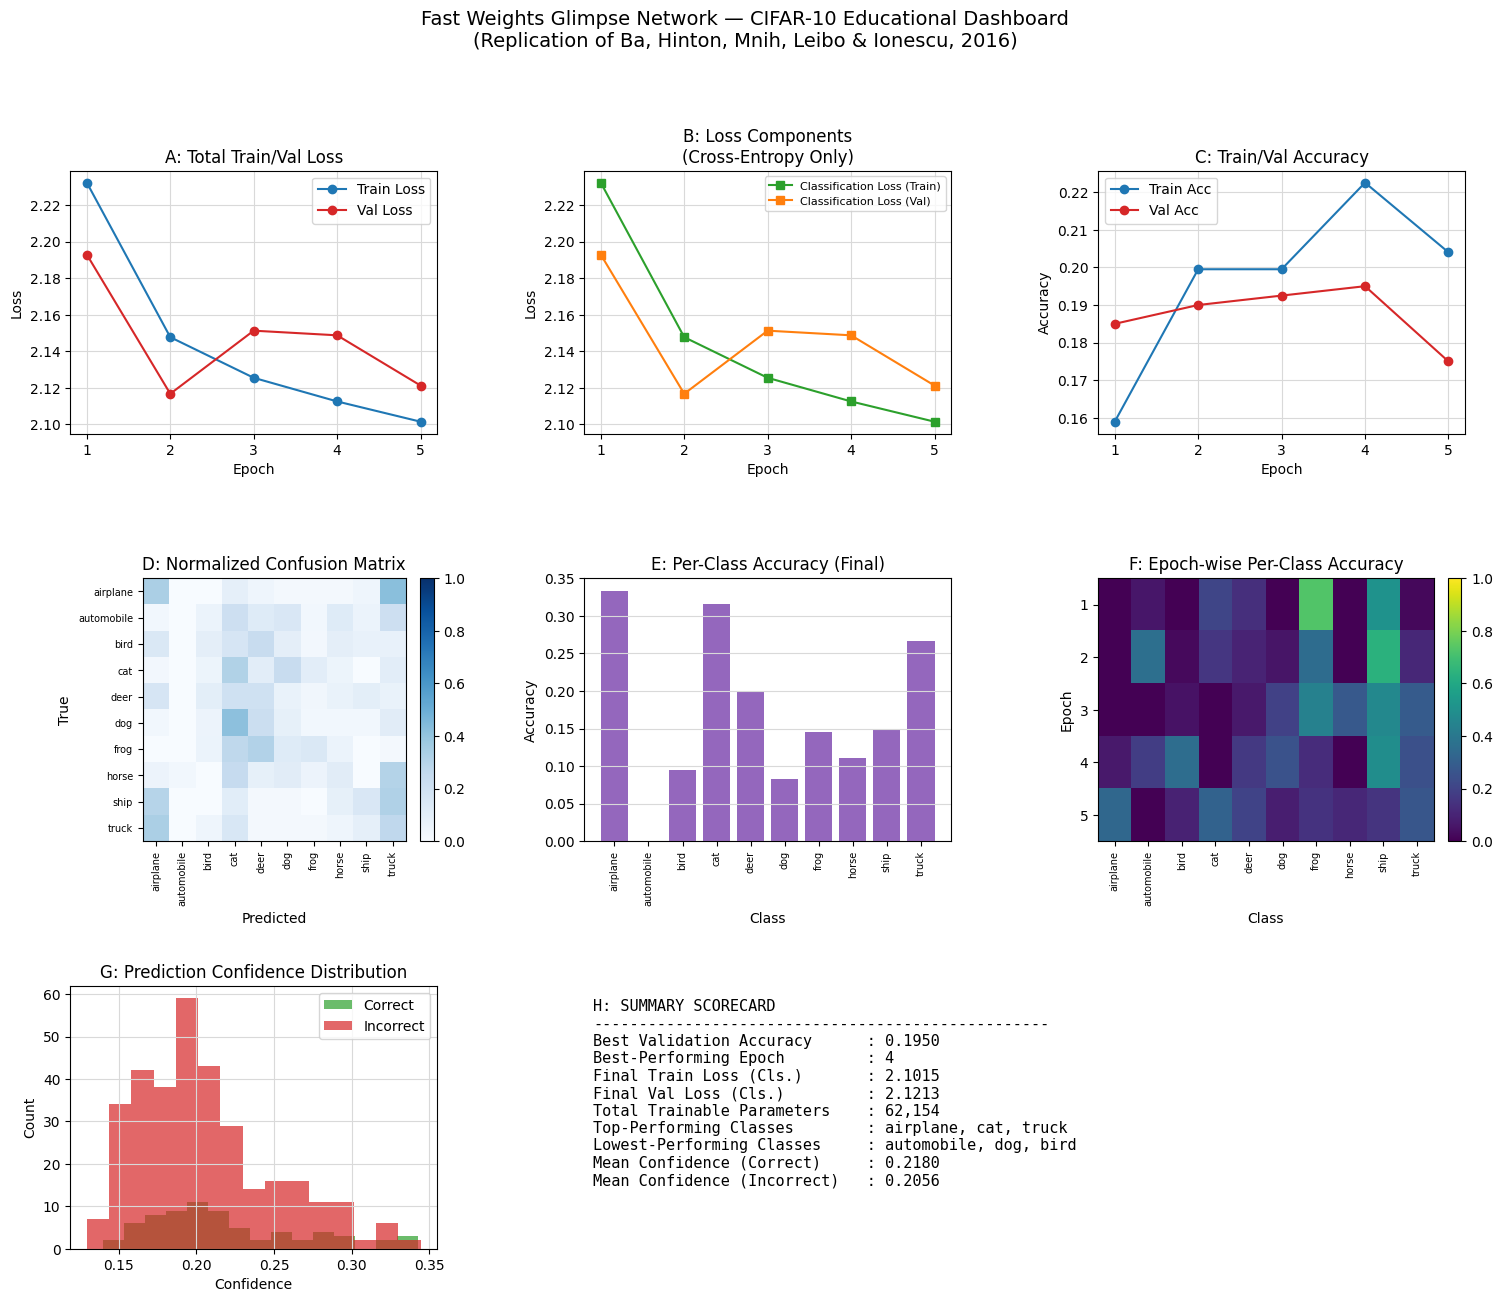

In [12]:
# ---------------------------------------------------------------
# DISPLAY DASHBOARD INLINE VIA BytesIO (no disk save, no plt.show())
# ---------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)

# Analysis of Experimental Results — Fast Weights Glimpse Network (Educational Replication)

## Overview
This dashboard reports a small-scale, educational replication of the fast-weights mechanism applied to CIFAR-10 classification via a glimpse-based recurrent architecture, trained for 5 epochs on a reduced subset (2,000 training / 400 test images). The panels jointly evaluate optimization behavior (loss, accuracy curves), classification quality (confusion matrix, per-class accuracy), memory/attention utilization across training (epoch-wise heatmap), and calibration (confidence distributions), consolidated with a numerical scorecard.

---

## Key Findings

**Panels A–C (Loss and Accuracy Curves).** Training loss decreases monotonically from ~2.23 to ~2.10, while training accuracy rises from 0.159 to a peak of 0.223 at epoch 4 before dipping. Validation loss and accuracy are non-monotonic: validation accuracy peaks at epoch 4 (0.195) but *declines* at epoch 5 (0.175) even as training accuracy continues to track upward, and validation loss rises between epochs 2 and 4 before falling again at epoch 5.

**Panel D (Confusion Matrix).** The normalized matrix shows diffuse, low-contrast probability mass across nearly all classes, with only weak diagonal dominance (max cell values around 0.3–0.4) for classes such as "airplane" and "truck." Several rows (e.g., "automobile," "bird") show near-uniform spread across many predicted classes.

**Panel E (Per-Class Accuracy).** Accuracy is highly uneven: "airplane" (~0.33), "cat" (~0.32), and "truck" (~0.27) are best-performing, whereas "automobile" is at essentially 0% accuracy, with "dog" and "bird" also low (<0.12).

**Panel F (Epoch-wise Per-Class Heatmap).** Per-class accuracy fluctuates substantially and non-systematically across epochs and classes, with no clear class showing stable, monotonic improvement; some classes (e.g., "ship" at epoch 1) show high transient accuracy that is not sustained.

**Panel G (Confidence Histogram).** Confidence scores for both correct and incorrect predictions are concentrated in a narrow, low-confidence band (~0.15–0.30), with heavy overlap between the two distributions.

**Panel H (Scorecard).** Best validation accuracy is 0.195 at epoch 4; total trainable parameters are only 62,154; mean confidence for correct (0.218) and incorrect (0.206) predictions are nearly indistinguishable.

---

## Discussion

The overall pattern is consistent with a substantially **under-trained and data-starved model** rather than a meaningful demonstration of the fast-weights mechanism's benefits. Accuracy levels (~15–22%) are only marginally above chance (10% for 10 classes), and the divergence between rising training accuracy and stagnant/declining validation accuracy after epoch 4 is a classic **overfitting signature** on a training set of only 2,000 images — far too small to learn discriminative visual features for a 10-way natural image task, especially through a low-capacity glimpse-based recurrent pathway with only ~62K parameters.

The near-total collapse of the "automobile" class (0% accuracy) alongside inconsistent per-class accuracy across epochs (Panel F) suggests the model has not converged to stable, generalizable class-specific representations; instead, it is likely fluctuating between locally memorized patterns from the small training pool. The confusion matrix's lack of strong diagonal structure corroborates this: classification is only weakly better than a diffuse random guess for most categories.

The confidence histogram result is informative from a **calibration standpoint**: the near-identical mean confidence for correct and incorrect predictions indicates the model has not learned to distinguish reliable from unreliable predictions—a common trait of models trained on insufficient data, where the softmax output does not yet encode meaningful epistemic uncertainty.

These results do **not** constitute evidence for or against the original paper's claims regarding fast weights' benefit over LSTM/RNN baselines, since no baseline comparison is included here, training duration (5 epochs) is minimal relative to the original paper's protocols, and the dataset subset is orders of magnitude smaller than typically required for CIFAR-10 (50,000 training images). This replication should be interpreted strictly as a **pedagogical demonstration of the fast-weights mechanism's mechanics and code structure**, not as a validation or refutation of the paper's empirical claims.

---

## Limitations

- **Severely reduced data scale** (2,000/400 images) and **short training horizon** (5 epochs) preclude any reliable assessment of model capability or convergence behavior.
- **No baseline comparison** (e.g., plain RNN, LSTM, or ConvNet) is included in this run, so the incremental value of the fast-weights mechanism cannot be assessed from these results alone.
- **Single-run evaluation**: no repeated trials or variance estimates are reported, so observed fluctuations (e.g., validation accuracy dip at epoch 5) cannot be distinguished from noise inherent to small-batch, small-dataset training.
- **Non-standard architecture deviations** from the original paper (CNN-based glimpse embedding, 4×4 fixed grid, reduced inner-loop steps) mean results are not directly comparable to the original paper's reported benchmarks (Tables 1–3).
- **Class imbalance in outcomes** (e.g., 0% accuracy for "automobile") may reflect an artifact of the tiny per-class sample count (~200 training images/class) rather than a fundamental limitation of the fast-weights mechanism itself.

# Related Work References

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hochreiter, S. & Schmidhuber, J. | 1997 | Long Short-Term Memory | Neural Computation | Introduces the LSTM architecture, used throughout as the primary baseline representing prior RNN memory mechanisms limited to $$O(H)$$ short-term capacity. |
| Hinton, G. E. & Plaut, D. C. | 1987 | Using Fast Weights to Deblur Old Memories | Proceedings of the Ninth Annual Conference of the Cognitive Science Society | Earliest proposal that fast weights could enable true recursion in neural networks; the current paper builds on and implements this previously unrealized idea. |
| Schmidhuber, J. | 1993 | Reducing the Ratio Between Learning Complexity and Number of Time-Varying Variables in Fully Recurrent Nets | ICANN '93 | Proposed that a fast-weight-based recursive system could be trained end-to-end via backpropagation, but did not implement it; this paper provides that missing implementation. |
| Tsodyks, M., Pawelzik, K., & Markram, H. | 1998 | Neural Networks with Dynamic Synapses | Neural Computation | Supports the physiological motivation for modeling temporary memory via synaptic dynamics rather than neural activations. |
| Abbott, L. F. & Regehr, W. G. | 2004 | Synaptic Computation | Nature | Provides evidence for short-term synaptic plasticity mechanisms operating at timescales relevant to the paper's fast-weight hypothesis. |
| Barak, O. & Tsodyks, M. | 2007 | Persistent Activity in Neural Networks with Dynamic Synapses | PLoS Computational Biology | Further supports the biological plausibility of dynamic-synapse-based temporary memory underlying the fast weights concept. |
| Zucker, R. S. & Regehr, W. G. | 2002 | Short-Term Synaptic Plasticity | Annual Review of Physiology | Describes synapse-specific facilitation/depression mechanisms, motivating the $$O(H^2)$$-capacity, synapse-like fast weight formulation. |
| Markram, H., Lubke, J., Frotscher, M., & Sakmann, B. | 1997 | Regulation of Synaptic Efficacy by Coincidence of Postsynaptic APs and EPSPs | Science | Cited as evidence for spike-timing-dependent plasticity as an intermediate-timescale synaptic mechanism paralleling fast weights. |
| Bi, G. & Poo, M. | 1998 | Synaptic Modifications in Cultured Hippocampal Neurons: Dependence on Spike Timing, Synaptic Strength, and Postsynaptic Cell Type | Journal of Neuroscience | Additional physiological evidence for timing-dependent synaptic plasticity supporting the biological basis of fast weights. |
| Willshaw, D. J., Buneman, O. P., & Longuet-Higgins, H. C. | 1969 | Non-Holographic Associative Memory | Nature | Foundational associative memory work underlying the outer-product storage rule adopted for fast weights. |
| Kohonen, T. | 1972 | Correlation Matrix Memories | IEEE Transactions on Computers | Early associative memory model contributing to the theoretical basis of storing patterns via weight matrices rather than explicit copies. |
| Anderson, J. A. & Hinton, G. E. | 1981 | Models of Information Processing in the Brain | Parallel Models of Associative Memory | Establishes the tradition of associative-memory-based neural models that fast weights extend. |
| Hopfield, J. J. | 1982 | Neural Networks and Physical Systems with Emergent Collective Computational Abilities | Proceedings of the National Academy of Sciences | Source of the Hopfield network and its outer-product storage rule, whose capacity bound ($$\approx 0.15N$$) contextualizes the paper's chosen storage rule. |
| Gardner, E. | 1988 | The Space of Interactions in Neural Network Models | Journal of Physics A | Provides theoretical capacity bounds for associative memories using iterative error-correction rules, contrasted with the simpler outer-product rule used in this paper. |
| Graves, A., Wayne, G., & Danihelka, I. | 2014 | Neural Turing Machines | arXiv preprint | Represents external-memory architectures compared against; the paper argues fast weights are simpler and more biologically plausible. |
| Grefenstette, E., Hermann, K. M., Suleyman, M., & Blunsom, P. | 2015 | Learning to Transduce with Unbounded Memory | NeurIPS | Cited as an alternative external-memory (Neural Stack) approach contrasted with the proposed fast associative memory. |
| Weston, J., Chopra, S., & Bordes, A. | 2014 | Memory Networks | arXiv preprint | Cited as another external-memory architecture requiring explicit addressing, motivating the simpler fast-weight alternative. |
| Bahdanau, D., Cho, K., & Bengio, Y. | 2015 | Neural Machine Translation by Jointly Learning to Align and Translate | ICLR | Source of the attention mechanism to which the fast-weight mechanism is compared; fast weights are shown to implement a similar attention effect without a separately parameterized alignment function. |
| Ba, J., Kiros, R., & Hinton, G. | 2016 | Layer Normalization | arXiv preprint | Introduces layer normalization, adopted in this paper to stabilize the fast-weight inner-loop dynamics. |
| Kingma, D. & Ba, J. | 2014 | Adam: A Method for Stochastic Optimization | arXiv preprint | Optimization algorithm used to train all models in the paper's experiments. |
| Danihelka, I., Wayne, G., Uria, B., Kalchbrenner, N., & Graves, A. | 2016 | Associative Long Short-Term Memory | arXiv preprint | Basis for the Associative LSTM baseline used for comparison in the associative retrieval experiment. |
| Mnih, V., Heess, N., Graves, A., & Kavukcuoglu, K. | 2014 | Recurrent Models of Visual Attention | NeurIPS | Introduces visual attention/glimpse models extended in this paper by integrating fast weights for multi-level glimpse storage; also source of the "Catch" RL task. |
| Ba, J., Mnih, V., & Kavukcuoglu, K. | 2015 | Multiple Object Recognition with Visual Attention | ICLR | Related visual attention model cited as part of the motivation for using fast weights to integrate glimpse information. |
| Xu, K., Ba, J., Kiros, R., Courville, A., Salakhutdinov, R., Zemel, R., & Bengio, Y. | 2015 | Show, Attend and Tell: Neural Image Caption Generation with Visual Attention | ICML | Cited as further evidence of visual attention models' success, motivating the extension to fast-weight-based glimpse integration. |
| Gross, R., Matthews, I., Cohn, J., Kanade, T., & Baker, S. | 2010 | Multi-PIE | Image and Vision Computing | Source of the MultiPIE facial expression dataset used in the facial expression recognition experiment. |
| Graves, A. | 2014 | Generating Sequences with Recurrent Neural Networks | arXiv preprint | Cited as prior work on memory and attention in supervised sequence learning, contextualizing the paper's extension to reinforcement learning. |
| Mnih, V., Badia, A. P., Mirza, M., Graves, A., Lillicrap, T. P., Harley, T., Silver, D., & Kavukcuoglu, K. | 2016 | Asynchronous Methods for Deep Reinforcement Learning | ICML | Provides the A3C algorithm used to train the reinforcement learning agents (RNN, LSTM, fast weights) in the "Catch" experiments. |